# Dataset Selection & Data Understanding
## Breast Cancer Wisconsin (Diagnostic) Dataset

**Assignment:** Select a suitable classification dataset and perform an initial
analysis to understand its structure and characteristics *before* starting the
machine-learning process.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — from the UCI Machine
Learning Repository, bundled in scikit-learn.

**Why this dataset**
- **569 records** (≥ 500 requirement satisfied) and **30 numeric features**.
- A genuine, well-documented **binary classification** problem: predict whether
  a tumour is **malignant** or **benign** from digitised images of a fine-needle
  aspirate (FNA).
- **Not** the Iris dataset (explicitly excluded by the brief).
- Real-world, medically meaningful, and clean enough to reason about while still
  showing class imbalance and strong feature correlations worth discussing.

### Objectives
1. Understand the dataset's structure.
2. Identify the target variable.
3. Explore the data (types, distributions, relationships).
4. Assess data quality (missing values, duplicates, class balance).
5. Prepare for the preprocessing stage.

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.3 | numpy 1.26.0


## 2. Load the Dataset

We load from the exported CSV so the notebook is fully reproducible from the
dataset file shipped with this assignment. If the CSV is missing, we fall back
to loading it directly from scikit-learn.

In [2]:
from pathlib import Path

csv_path = Path("breast_cancer_wisconsin.csv")

if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(f"Loaded from CSV: {csv_path}")
else:
    from sklearn.datasets import load_breast_cancer
    ds = load_breast_cancer(as_frame=True)
    df = ds.frame.copy()
    df["diagnosis"] = df["target"].map({0: "malignant", 1: "benign"})
    print("Loaded from scikit-learn")

df.head()

Loaded from CSV: breast_cancer_wisconsin.csv


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


**Column notes**

- The 30 feature columns describe cell-nucleus characteristics. Each of ten base
  measurements (*radius, texture, perimeter, area, smoothness, compactness,
  concavity, concave points, symmetry, fractal dimension*) appears three times:
  the **mean**, the **standard error (`error`)**, and the **worst / largest
  (`worst`)** value across the nuclei in the image.
- `target` is the scikit-learn integer encoding: **0 = malignant, 1 = benign**.
- `diagnosis` is the human-readable label we added for analysis and plotting.

## 3. Dataset Structure — Rows, Columns & Data Types

In [3]:
n_rows, n_cols = df.shape
print(f"Number of rows (records):   {n_rows}")
print(f"Number of columns (total):  {n_cols}")

feature_cols = [c for c in df.columns if c not in ("target", "diagnosis")]
print(f"Feature columns:            {len(feature_cols)}")
print(f"Label/target columns:       {['target', 'diagnosis']}")

Number of rows (records):   569
Number of columns (total):  32
Feature columns:            30
Label/target columns:       ['target', 'diagnosis']


In [4]:
# Full structural overview: dtypes + non-null counts + memory
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [5]:
# How many columns of each data type?
df.dtypes.value_counts()

float64    30
int64       1
str         1
Name: count, dtype: int64

**Observation.** All 30 features are continuous **float64** measurements. The
only non-numeric column is the `diagnosis` label we added (object/string).
`target` is an integer encoding of that same label. There are **no categorical
feature columns** to encode — the modelling work will centre on *scaling*, not
encoding.

## 4. Identify the Target Variable

In [6]:
print("Target variable: 'diagnosis'  (encoded as 'target': 0 = malignant, 1 = benign)")
print("Task type      : Binary classification")
print()
print("Unique target values:")
print(df["diagnosis"].value_counts())

Target variable: 'diagnosis'  (encoded as 'target': 0 = malignant, 1 = benign)
Task type      : Binary classification

Unique target values:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


The target is **`diagnosis`** — a two-class label (`malignant` / `benign`).
This is a **supervised binary classification** problem. `target` (0/1) is the
model-ready numeric form of the same variable; we keep both but will train on
`target` and read `diagnosis` for interpretation.

## 5. Data Quality — Missing Values & Duplicates

In [7]:
missing = df.isnull().sum()
print("Total missing values across the whole dataset:", int(missing.sum()))
print()
cols_with_missing = missing[missing > 0]
if cols_with_missing.empty:
    print("No column contains missing values.")
else:
    print("Columns with missing values:")
    print(cols_with_missing)

Total missing values across the whole dataset: 0

No column contains missing values.


In [8]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

Duplicate rows: 0


**Observation.** The dataset is complete — **0 missing values** and **0
duplicate rows**. This is unusual for real-world data and means the preprocessing
stage will not need imputation or de-duplication. We still document the check
because *verifying* the absence of missing data is itself part of data
understanding.

## 6. Descriptive Statistics

In [9]:
df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


**Observation — features are on very different scales.** For example `area`
features run into the thousands while `smoothness` and `fractal dimension` sit
below 1. Distance- and gradient-based models (kNN, SVM, logistic regression,
neural nets) will therefore require **feature scaling / standardisation** during
preprocessing.

## 7. Class Distribution (Target Balance)

In [10]:
counts = df["diagnosis"].value_counts()
pct = (counts / len(df) * 100).round(2)
balance = pd.DataFrame({"count": counts, "percent": pct})
print(balance)
print()
ratio = counts.max() / counts.min()
print(f"Imbalance ratio (majority : minority) = {ratio:.2f} : 1")

           count  percent
diagnosis                
benign       357    62.74
malignant    212    37.26

Imbalance ratio (majority : minority) = 1.68 : 1


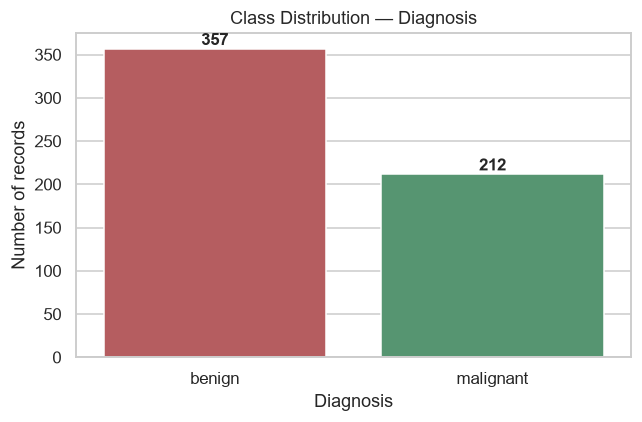

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
order = ["benign", "malignant"]
sns.countplot(data=df, x="diagnosis", order=order,
              hue="diagnosis", palette=["#4C9F70", "#C44E52"], legend=False, ax=ax)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Class Distribution — Diagnosis")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Number of records")
plt.tight_layout()
plt.savefig("figures/01_class_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

**Observation.** The classes are **moderately imbalanced**: ~63% benign vs ~37%
malignant (≈ 1.68 : 1). Not severe, but enough that we should:
- prefer **stratified** train/test splits and cross-validation, and
- report **precision, recall and F1** (not just accuracy), since in a cancer
  setting a false negative — missing a malignant tumour — is the costly error.

## 8. Feature Distributions

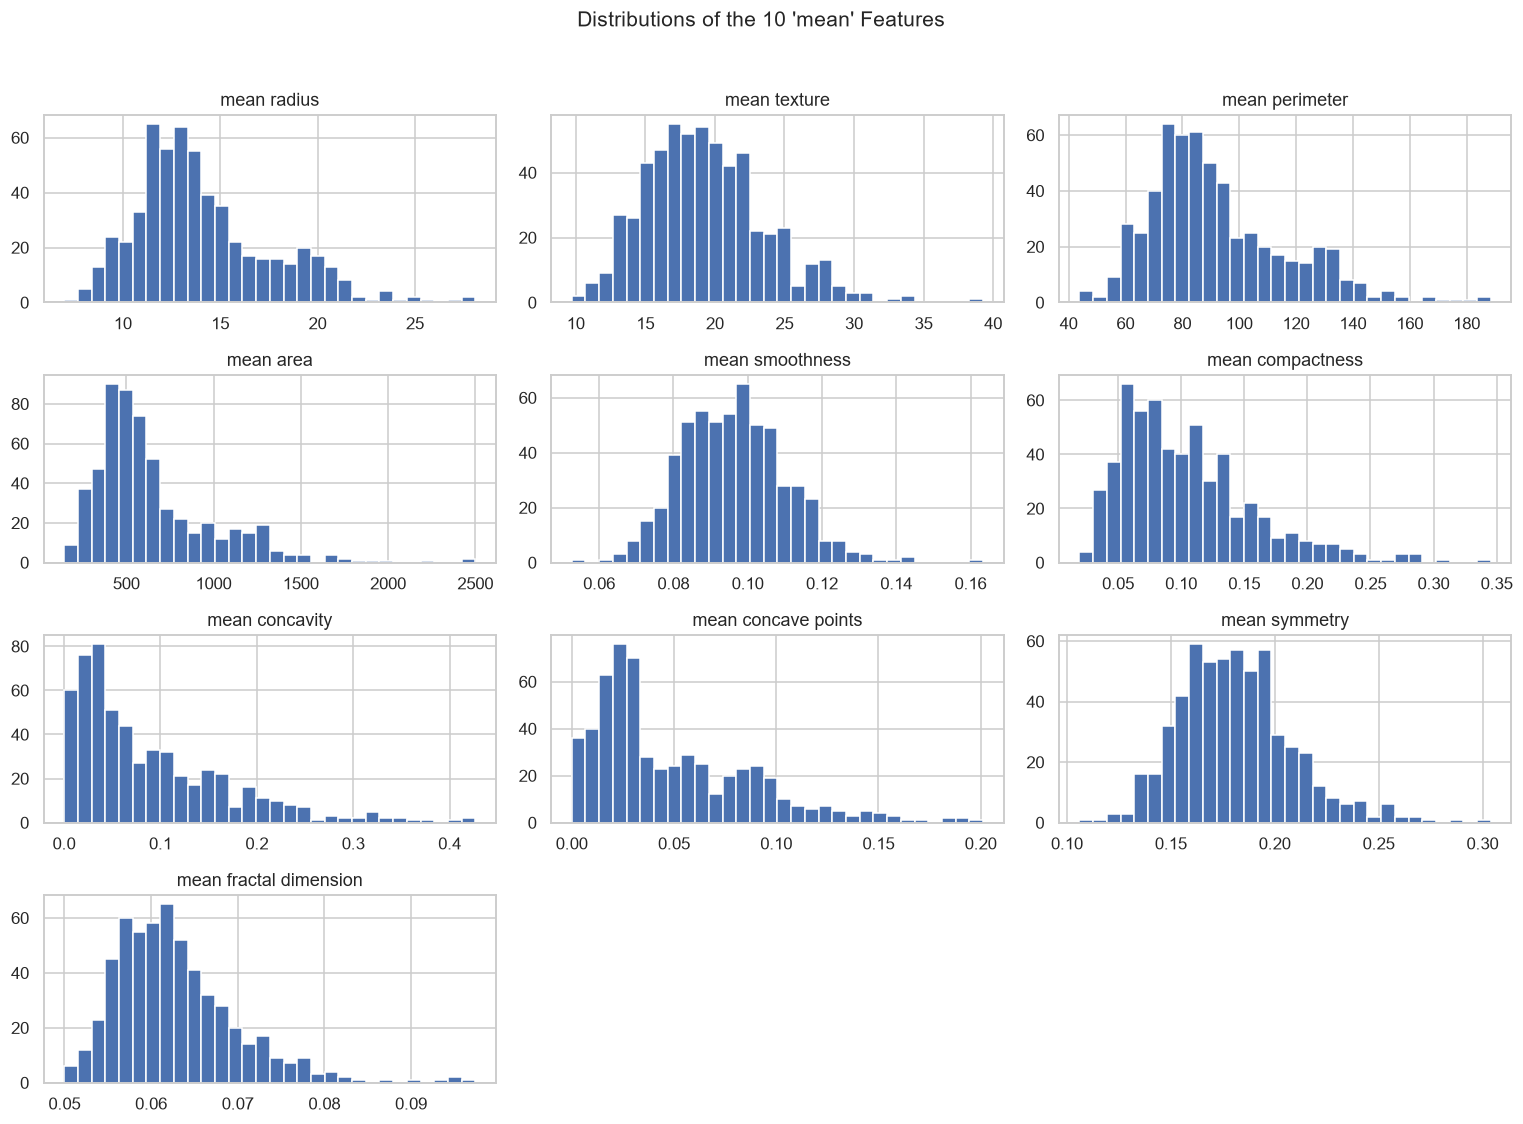

In [12]:
# Focus on the 10 'mean' features for readable histograms
mean_features = [c for c in feature_cols if c.startswith("mean ")]

axes = df[mean_features].hist(figsize=(14, 10), bins=30, color="#4C72B0",
                              edgecolor="white")
plt.suptitle("Distributions of the 10 'mean' Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("figures/02_feature_histograms.png", dpi=130, bbox_inches="tight")
plt.show()

**Observation.** Several features (`mean area`, `mean concavity`, `mean concave
points`) are **right-skewed**, hinting that a log or power transform *may* help
some linear models. Others are roughly bell-shaped.

## 9. How Well Do Features Separate the Two Classes?

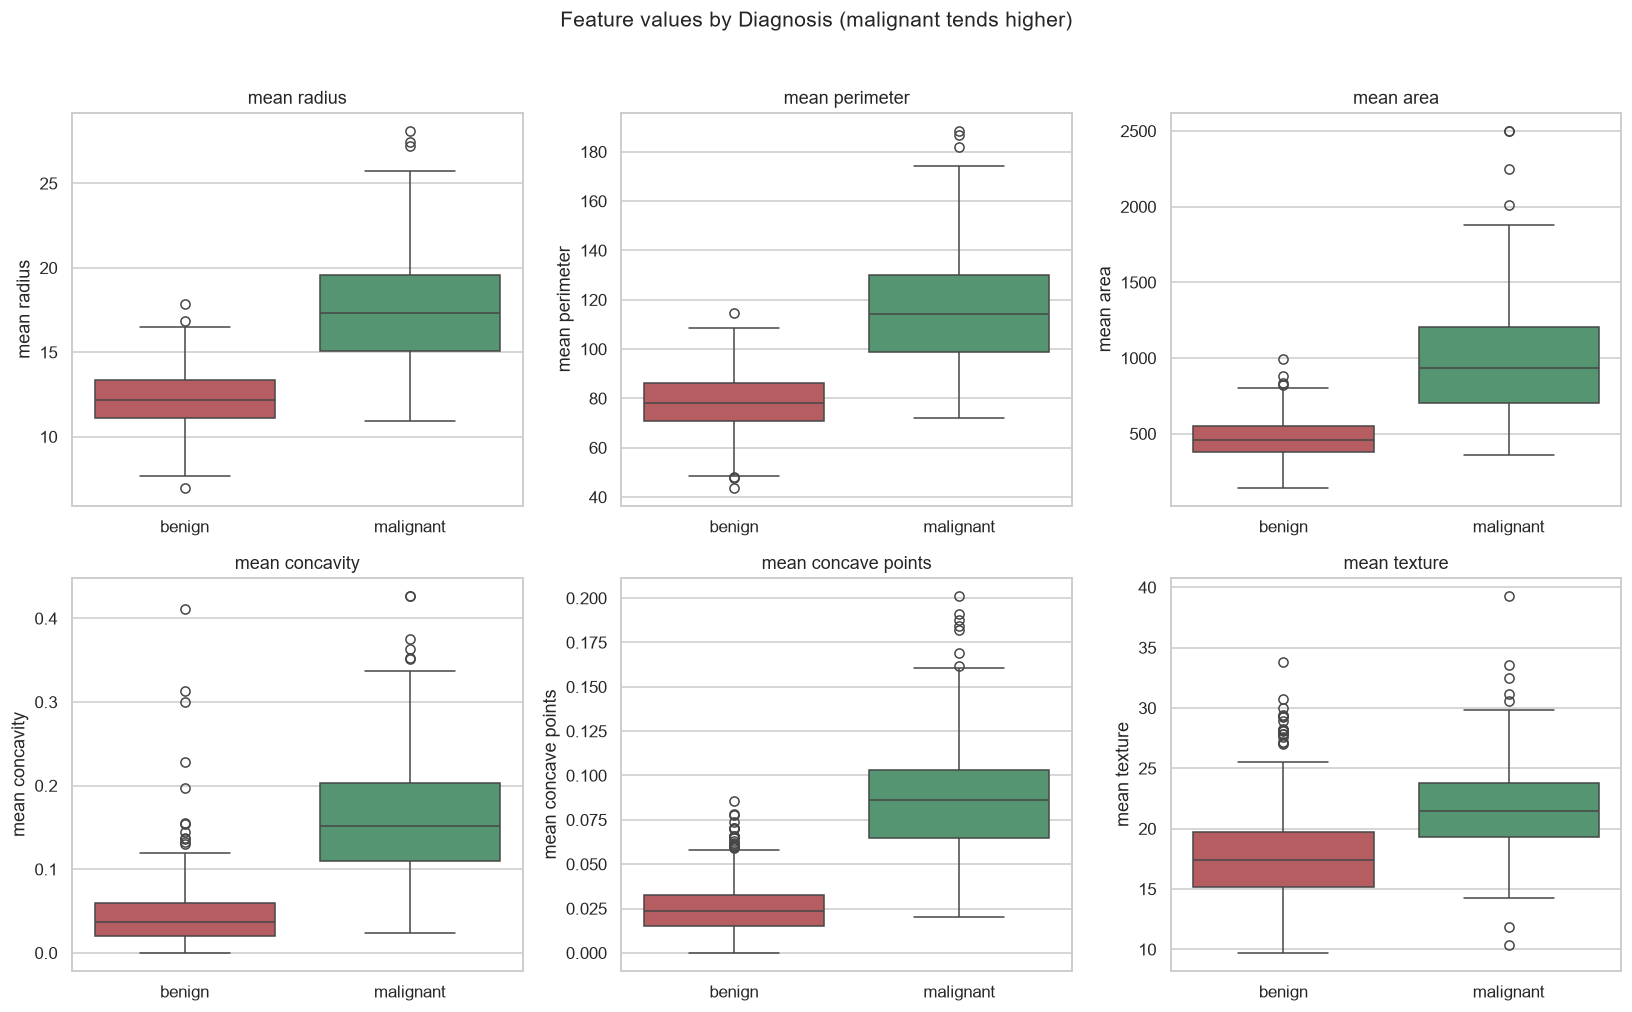

In [13]:
# Boxplots of a few discriminative 'mean' features, split by diagnosis
show = ["mean radius", "mean perimeter", "mean area",
        "mean concavity", "mean concave points", "mean texture"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, feat in zip(axes.ravel(), show):
    sns.boxplot(data=df, x="diagnosis", y=feat, order=order,
                hue="diagnosis", palette=["#4C9F70", "#C44E52"],
                legend=False, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("")
plt.suptitle("Feature values by Diagnosis (malignant tends higher)", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig("figures/03_boxplots_by_class.png", dpi=130, bbox_inches="tight")
plt.show()

**Observation.** Malignant tumours consistently show **larger** radius,
perimeter, area, concavity and concave-point values. These size/shape features
look **strongly predictive**, which is encouraging for downstream modelling.

## 10. Feature Correlations

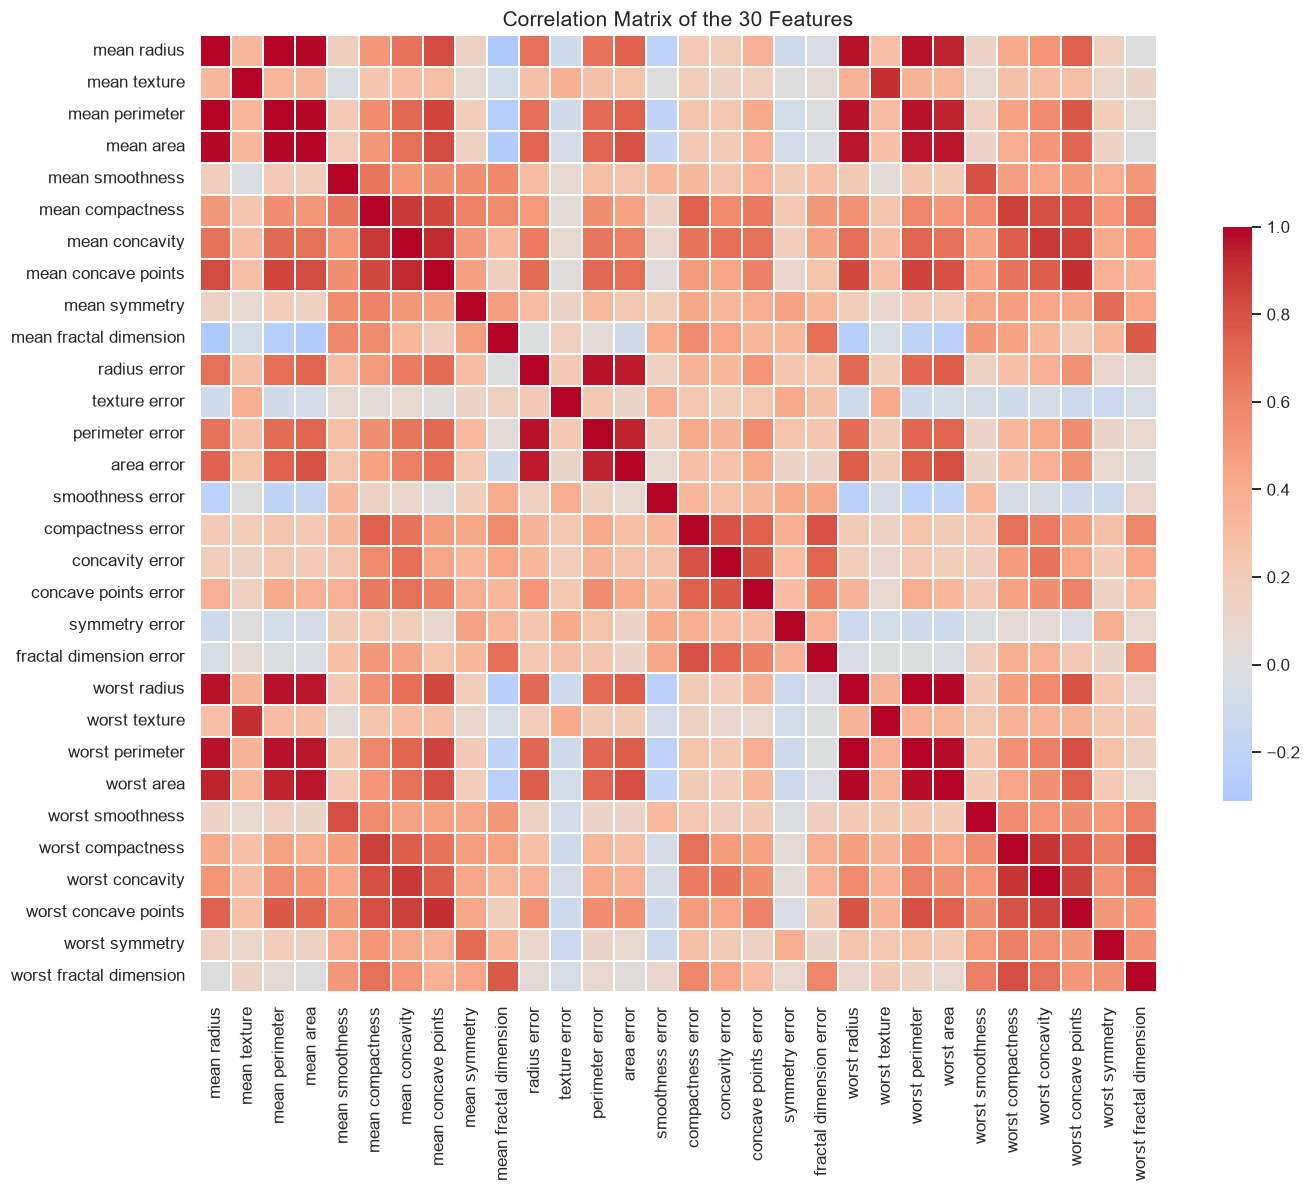

In [14]:
corr = df[feature_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.6}, linewidths=0.3)
plt.title("Correlation Matrix of the 30 Features", fontsize=14)
plt.tight_layout()
plt.savefig("figures/04_correlation_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

In [15]:
# Highly correlated feature pairs (|r| > 0.9) — candidates for redundancy
corr_abs = corr.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b", 0: "abs_corr"})
)
high_pairs = high_pairs[high_pairs["abs_corr"] > 0.9].sort_values(
    "abs_corr", ascending=False
)
print(f"{len(high_pairs)} feature pairs with |correlation| > 0.9")
high_pairs.head(15)

21 feature pairs with |correlation| > 0.9


,feature_a,feature_b,abs_corr
2,mean radius,mean perimeter,0.997855
622,worst radius,worst perimeter,0.993708
3,mean radius,mean area,0.987357
63,mean perimeter,mean area,0.986507
623,worst radius,worst area,0.984015
683,worst perimeter,worst area,0.977578
312,radius error,perimeter error,0.972794
82,mean perimeter,worst perimeter,0.970387
20,mean radius,worst radius,0.969539
80,mean perimeter,worst radius,0.969476


**Observation.** Many features are **highly correlated** — unsurprising, since
`radius`, `perimeter` and `area` are geometrically linked, and each base
measurement repeats as *mean / error / worst*. This **multicollinearity**
suggests dimensionality reduction (PCA) or feature selection could be explored
in preprocessing, and warns against interpreting individual coefficients of a
linear model too literally.

## 11. Correlation of Each Feature with the Target

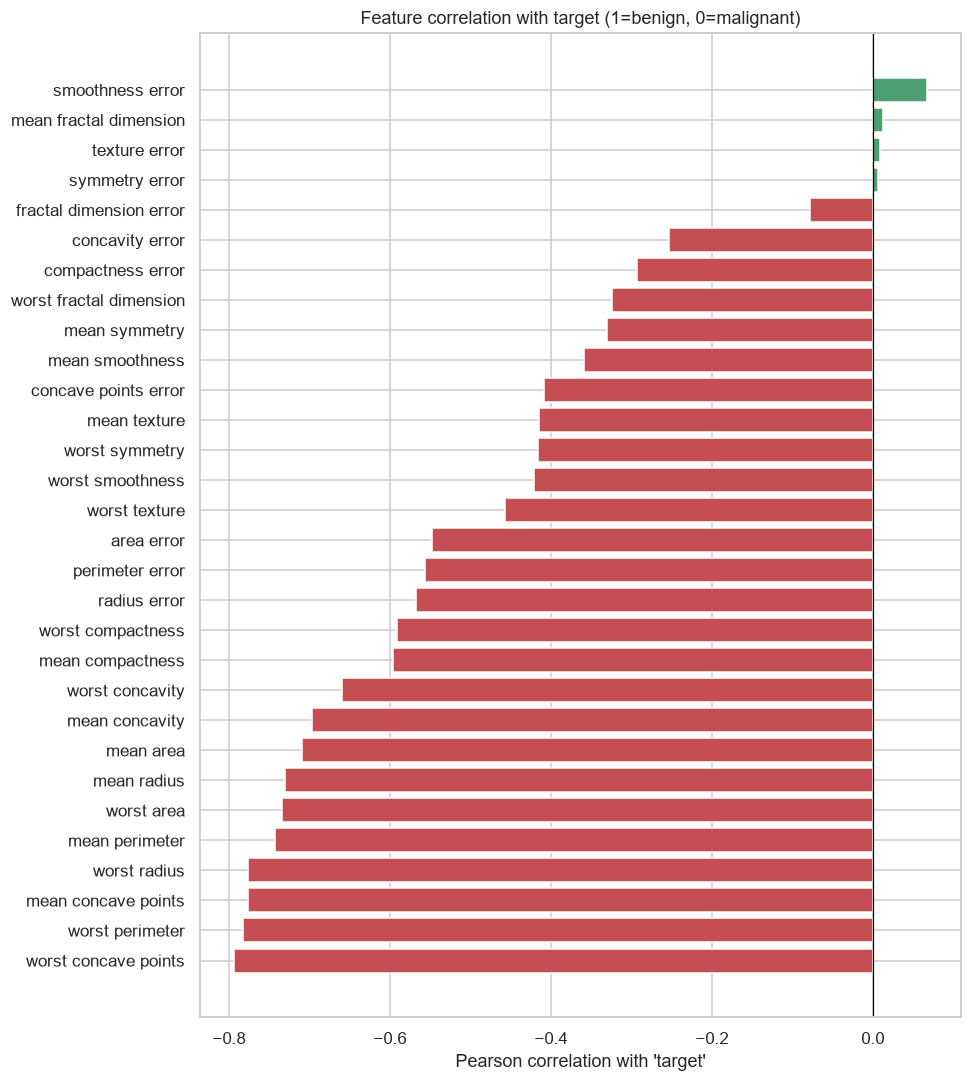

In [16]:
target_corr = (
    df[feature_cols + ["target"]].corr()["target"]
    .drop("target")
    .sort_values()
)

plt.figure(figsize=(9, 10))
colors = ["#C44E52" if v < 0 else "#4C9F70" for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature correlation with target (1=benign, 0=malignant)")
plt.xlabel("Pearson correlation with 'target'")
plt.tight_layout()
plt.savefig("figures/05_target_correlation.png", dpi=130, bbox_inches="tight")
plt.show()

**Observation.** Because `target` encodes benign=1, features that are **large in
malignant tumours** correlate **negatively** with the target. The strongest
signals (`worst concave points`, `worst perimeter`, `worst radius`, `mean
concave points`) are exactly the size/shape features the boxplots highlighted.

## 12. Summary & Readiness for Preprocessing

### What we learned
| Aspect | Finding |
|---|---|
| Records × columns | **569 rows × 32 columns** (30 features + `target` + `diagnosis`) |
| Feature types | All 30 features are continuous **float64**; no categorical features |
| Target variable | **`diagnosis`** (`malignant` / `benign`), encoded as `target` 0/1 |
| Task | **Binary classification** |
| Missing values | **None** (0) |
| Duplicate rows | **None** (0) |
| Class balance | Benign ~63% vs Malignant ~37% (**≈1.68:1**, moderate imbalance) |
| Feature scales | Very different (area in thousands vs smoothness < 1) → **scaling needed** |
| Correlations | Strong **multicollinearity**; size/shape features most predictive |

### Implications for the preprocessing stage
1. **No imputation / de-duplication needed** — data is complete and unique.
2. **Feature scaling is essential** (StandardScaler) given the wide value ranges.
3. **No categorical encoding needed** — features are already numeric; only the
   target label needs its 0/1 encoding (already provided as `target`).
4. **Use a stratified train/test split** and stratified cross-validation to
   preserve the class ratio.
5. **Evaluate with precision / recall / F1 / ROC-AUC**, not accuracy alone —
   false negatives (missed malignancies) are the expensive error.
6. **Consider dimensionality reduction / feature selection** (PCA or dropping
   near-duplicate features) to address the heavy multicollinearity.

The dataset is well understood and ready for the preprocessing and modelling
stages.